# RL-обучение юнитов в BitBattles

Этот ноутбук запускает cервер, который получает состояние поля из Unity, предсказывает действия через нейросеть DQN и визуализирует процесс красивыми графиками.

## Импорты нужных модулей

In [22]:
import socket
import json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import random
import os
import threading
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

## Класс нейросети

In [23]:
class DQN(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, output_size)
        )

    def forward(self, x):
        return self.net(x)

## Как работает система:

### 1. Unity отправляет состояние юнита (27 чисел)
Каждый юнит видит себя, ближайшего врага и соседние клетки, а так же их типы.
Unity собирает эти данные в массив из 27 чисел и отправляет JSON через TCP-сокет.
Пример одного состояния:
`[0.5, 0.3, 0.8, 0.33, 0.33, 0.6, 0.7, 0.67, 1, 0, 0, 0, 0, 0, 2, -1, 0, ...]`

## Как работает система (по шагам)

### 1. Unity отправляет состояние юнита (27 чисел)
Каждый юнит «видит» себя, ближайшего врага, соседние клетки, дальние клетки и флаг укрытия.
Unity собирает эти данные в массив из 27 чисел и отправляет JSON через TCP-сокет.

#### Структура состояния (27 чисел)

| Индекс | Описание | Диапазон | Пример |
|--------|----------|----------|--------|
| 0 | X-координата юнита (нормализованная: 0–4 → 0–1) | 0.0 – 1.0 | 0.5 |
| 1 | Y-координата юнита (нормализованная: 0–9 → 0–1) | 0.0 – 1.0 | 0.3 |
| 2 | Текущее HP (нормализованное: 0–maxHP → 0–1) | 0.0 – 1.0 | 0.8 |
| 3 | Уровень юнита (1/3, 2/3, 3/3) | 0.33, 0.67, 1.0 | 0.33 |
| 4 | Тип юнита (1=Knight, 2=Archer, 3=Mage) | 0.33, 0.67, 1.0 | 0.33 |
| 5 | X-координата ближайшего врага (−1 если нет) | -1.0 – 1.0 | 0.6 |
| 6 | Y-координата ближайшего врага (−1 если нет) | -1.0 – 1.0 | 0.7 |
| 7 | Тип ближайшего врага (0 если нет) | 0.0 – 1.0 | 0.67 |
| 8 | Враг в радиусе атаки? (0/1) | 0 или 1 | 1 |
| 9–16 | 8 соседних клеток (радиус 1): -1=стена, 0=пусто, 1=свой, 2=враг, -2=камень, 3=хилка | -2 – 3 | см. схему |
| 17–25 | 9 клеток на расстоянии атаки (attackRange): те же значения | -2 – 3 | см. схему |
| 26 | За камнем относительно врага? (0/1) – только для Archer/Mage | 0 или 1 | 1 |

### 2. Нейросеть предсказывает действие (0–4)
Сервер получает 27 чисел и передаёт их в нейросеть.
Нейросеть состоит из трёх слоёв: 27 → 64 → 64 → 5.
Она выдаёт 5 Q-значений – по одному на каждое возможное движение:
0 – стоять, 1 – вверх, 2 – вниз, 3 – влево, 4 – вправо.
Выбирается действие с максимальным Q-значением (или случайное, если exploration включён).

### 3. Юнит выполняет действие и получает награду
Unity получает номер действия, двигает юнита (или оставляет на месте) и сразу атакует, если враг в радиусе.
Затем вычисляется награда:
- +5 за убийство врага
- +0.1 за каждую единицу здоровья больше, чем на предыдущем шаге
- +0.01 за приближение к врагу на 1 клетку
- +0.5 за укрытие за камнем (для Archer/Mage)
- +3 за подбор хилки (если HP выросло без атаки)
- -10 за смерть

### 4. Опыт сохраняется в память, нейросеть дообучается
Каждый шаг (состояние, действие, награда, следующее состояние) сохраняется в Replay Buffer (до 2000 записей).
Когда в буфере накапливается минимум 32 записи, нейросеть обучается на случайной выборке из буфера.
Обучение идёт через Q-learning с минимизацией MSE между предсказанными Q и целевыми Q.

### 5. Метрики и модель сохраняются каждые 50 шагов
Собираются метрики:
- **Loss** – ошибка нейросети (должна падать)
- **Epsilon** – шанс случайного действия (уменьшается)
- **Memory Size** – сколько опыта в буфере
- **Average Reward** – средняя награда за эпизод (должна расти)

Каждые 50 шагов модель (`rl_model.pth`) и метрики (`metrics.json`) сохраняются на диск.

## RL-агент с памятью и метриками

Агент хранит опыт в буфере (Replay Buffer), обучается через Q-learning с нейросетью.
Собирает метрики: **loss**, **epsilon**, **размер памяти**, **средняя награда за эпизод**.

## Класс RL-агента

In [24]:
class RLAgent:
    def __init__(self, state_size, action_size, lr=0.001):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95
        self.epsilon = 0.3
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995
        self.batch_size = 32
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.model = DQN(state_size, action_size).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

        self.step_count = 0
        self.episode_reward = 0
        self.metrics = {'loss': [], 'epsilon': [], 'avg_reward': [], 'memory_size': []}

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state, explore=True):
        if explore and np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        with torch.no_grad():
            q_values = self.model(state_t)
        return torch.argmax(q_values).item()

    def replay(self):
        if len(self.memory) < self.batch_size:
            return None

        minibatch = random.sample(self.memory, self.batch_size)
        states, actions, rewards, next_states, dones = zip(*minibatch)

        states_t = torch.tensor(np.array(states), dtype=torch.float32).to(self.device)
        actions_t = torch.tensor(actions, dtype=torch.long).unsqueeze(1).to(self.device)
        rewards_t = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1).to(self.device)
        next_states_t = torch.tensor(np.array(next_states), dtype=torch.float32).to(self.device)
        dones_t = torch.tensor(dones, dtype=torch.float32).unsqueeze(1).to(self.device)

        # Текущие Q-значения для выбранных действий
        q_values = self.model(states_t).gather(1, actions_t)

        # Целевые Q-значения по Беллману (без numpy!)
        with torch.no_grad():
            max_next_q = self.model(next_states_t).max(dim=1, keepdim=True)[0]
            targets = rewards_t + self.gamma * max_next_q * (1 - dones_t)

        loss = self.loss_fn(q_values, targets)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        self.step_count += 1
        self.metrics['loss'].append(loss.item())
        self.metrics['epsilon'].append(self.epsilon)
        self.metrics['memory_size'].append(len(self.memory))

        return loss.item()

    def save(self, path="rl_model.pth"):
        torch.save(self.model.state_dict(), path)

    def load(self, path="rl_model.pth"):
        if os.path.exists(path):
            self.model.load_state_dict(torch.load(path, map_location=self.device))
            print("Модель загружена")
        else:
            print("Модель не найдена, используется новая")

    def save_metrics(self, path="metrics.json"):
        with open(path, 'w') as f:
            json.dump(self.metrics, f)

## Визуализация

Рисуем 4 графика:
- **Loss** – как быстро учится нейросеть (должен падать)
- **Epsilon** – шанс случайного действия (уменьшается)
- **Memory Size** – сколько опыта накоплено
- **Average Reward** – награда за эпизод (должна расти)

## Функция plot_metrics


## Как читать графики обучения

Функция `plot_metrics()` отрисовывает четыре ключевых показателя тренировки нейросети.
Вот что означает каждый график и как понять, что обучение идёт успешно.

---

### 1. Loss (ошибка)
Показывает, насколько сильно предсказания нейросети отличаются от целевых значений Q-learning.
- **Хороший признак:** график постепенно снижается или держится на низком уровне.
- **Плохой признак:** Loss растёт или сильно колеблется без тренда вниз.
- **Норма:** сначала может быть высоким (0.5–2.0), затем опускается до 0.01–0.1.

---

### 2. Epsilon (степень исследования)
Это вероятность того, что агент выберет случайное действие вместо того, чтобы довериться нейросети.
- **Хороший признак:** Epsilon плавно уменьшается от 0.3 до 0.05.
- **Плохой признак:** застрял на одном значении или уменьшился слишком быстро.
- **Норма:** за 500–1000 шагов должен упасть до ~0.1.

---

### 3. Memory Size (размер памяти)
Количество записей в Replay Buffer — «опыт», накопленный агентом.
- **Хороший признак:** быстро растёт в начале, затем стабилизируется около 2000 (максимум).
- **Плохой признак:** не растёт или падает (значит, данные не сохраняются).

---

### 4. Avg Reward per Episode (средняя награда за эпизод)
Средняя награда, полученная юнитом за один игровой эпизод (раунд).
- **Хороший признак:** график уверенно идёт вверх.
- **Плохой признак:** стоит на месте или падает — агент не учится.
- **Норма:** может начинаться с отрицательных значений (-5…-10), затем подниматься до +5…+20.

---

> **Общий вывод:** если Loss падает, Epsilon уменьшается, память заполнена, а награда растёт — нейросеть обучается правильно.

In [25]:
def plot_metrics(agent):
    data = agent.metrics
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    if data['loss']:
        axes[0,0].plot(data['loss'][::5])
        axes[0,0].set_title('Loss')
        axes[0,0].set_xlabel('Step')
        axes[0,0].set_ylabel('Loss')

    if data['epsilon']:
        axes[0,1].plot(data['epsilon'])
        axes[0,1].set_title('Epsilon (exploration)')
        axes[0,1].set_xlabel('Step')

    if data['memory_size']:
        axes[1,0].plot(data['memory_size'])
        axes[1,0].set_title('Memory Size')
        axes[1,0].set_xlabel('Step')

    if data['avg_reward']:
        axes[1,1].plot(data['avg_reward'])
        axes[1,1].set_title('Avg Reward per Episode')
        axes[1,1].set_xlabel('Episode')

    plt.tight_layout()
    plt.show()

## TCP-сервер

Запускается в фоновом потоке. Принимает JSON из Unity с состоянием юнита, возвращает действие.
Автосохранение модели и метрик каждые 50 шагов.

In [30]:
import sys, threading, socket, json, time
import matplotlib.pyplot as plt
from IPython.display import clear_output

HOST = '127.0.0.1'
PORT = 65432
STATE_SIZE = 27
ACTION_SIZE = 5

agent = RLAgent(STATE_SIZE, ACTION_SIZE)
agent.load()

print(f"RL сервер стартует на {HOST}:{PORT}")
print(f"Состояние: {STATE_SIZE} чисел, Действий: {ACTION_SIZE}")

stop_server = False
round_actions = 0
round_reward = 0
last_print_time = time.time()

def run_server():
    global stop_server, round_actions, round_reward, last_print_time
    try:
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            s.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
            s.bind((HOST, PORT))
            s.listen()
            s.settimeout(1)
            print('Ожидание подключения...', flush=True)
            conn = None
            while not stop_server:
                try:
                    conn, addr = s.accept()
                    break
                except socket.timeout:
                    continue
            if stop_server:
                return

            print('Подключён:', addr, flush=True)

            last_experience = {}

            with conn:
                while not stop_server:
                    try:
                        conn.settimeout(1)
                        data = conn.recv(4096)
                    except socket.timeout:
                        # ВОТ ТУТ проверяем таймер
                        if time.time() - last_print_time >= 5:
                            print(f"\n--- Статистика ---", flush=True)
                            print(f"Шагов: {agent.step_count}, ε={agent.epsilon:.3f}, Память: {len(agent.memory)}", flush=True)
                            print(f"Действий: {round_actions}, Награда: {round_reward:.2f}", flush=True)
                            print(f"------------------\n", flush=True)
                            round_actions = 0
                            round_reward = 0
                            last_print_time = time.time()
                        continue
                    except:
                        break

                    if not data:
                        break
                    try:
                        msg = json.loads(data.decode().strip())
                        state = msg.get('state', [])
                        reward = msg.get('reward', 0)
                        done = msg.get('done', False)
                        unit_id = msg.get('unit_id', 'none')

                        if len(state) < STATE_SIZE:
                            state += [0.0] * (STATE_SIZE - len(state))
                        else:
                            state = state[:STATE_SIZE]

                        if unit_id in last_experience:
                            prev_state, prev_action = last_experience[unit_id]
                            agent.remember(prev_state, prev_action, reward, state, done)
                            agent.replay()

                        action = agent.act(state)
                        last_experience[unit_id] = (state, action)

                        round_actions += 1
                        round_reward += reward

                        if done:
                            agent.metrics['avg_reward'].append(agent.episode_reward)
                            agent.episode_reward = 0
                            if unit_id in last_experience:
                                del last_experience[unit_id]
                        else:
                            agent.episode_reward += reward

                        response = json.dumps({"action": action})
                        conn.sendall((response + '\n').encode())

                        if agent.step_count % 50 == 0 and agent.step_count > 0:
                            agent.save()
                            agent.save_metrics()
                            print(f"💾 Модель сохранена (шаг {agent.step_count})", flush=True)

                    except Exception as e:
                        print("Ошибка:", e, flush=True)
                        break

        agent.save()
        agent.save_metrics()
        print("Сервер остановлен, модель и метрики сохранены", flush=True)
    except Exception as e:
        print(f"КРИТИЧЕСКАЯ ОШИБКА: {e}", flush=True)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()
time.sleep(0.3)

if not server_thread.is_alive():
    print("Поток сервера НЕ ЗАПУСТИЛСЯ!", flush=True)
else:
    print("Сервер запущен. Ожидание боя...", flush=True)
    print("Запусти Unity и начни бой!", flush=True)
    try:
        while server_thread.is_alive():
            time.sleep(0.5)
    except KeyboardInterrupt:
        print("\nОстановка сервера...", flush=True)
        stop_server = True
        time.sleep(1)

Модель загружена
RL сервер стартует на 127.0.0.1:65432
Состояние: 27 чисел, Действий: 5
Ожидание подключения...
Сервер запущен. Ожидание боя...
Запусти Unity и начни бой!
Подключён: ('127.0.0.1', 57916)

--- Статистика ---
Шагов: 0, ε=0.300, Память: 0
Действий: 0, Награда: 0.00
------------------


--- Статистика ---
Шагов: 0, ε=0.300, Память: 0
Действий: 0, Награда: 0.00
------------------


--- Статистика ---
Шагов: 0, ε=0.300, Память: 0
Действий: 0, Награда: 0.00
------------------


--- Статистика ---
Шагов: 26, ε=0.263, Память: 57
Действий: 62, Награда: -1.31
------------------


--- Статистика ---
Шагов: 26, ε=0.263, Память: 57
Действий: 0, Награда: 0.00
------------------

💾 Модель сохранена (шаг 50)
💾 Модель сохранена (шаг 100)

--- Статистика ---
Шагов: 108, ε=0.175, Память: 139
Действий: 82, Награда: 3.66
------------------

Сервер остановлен, модель и метрики сохранены


## Живое обновление графиков

Каждые 5 секунд графики обновляются.
Чтобы остановить, выполнить `stop_server = True` в отдельной ячейке или остановить ноутбук.

##### Цикл обновления

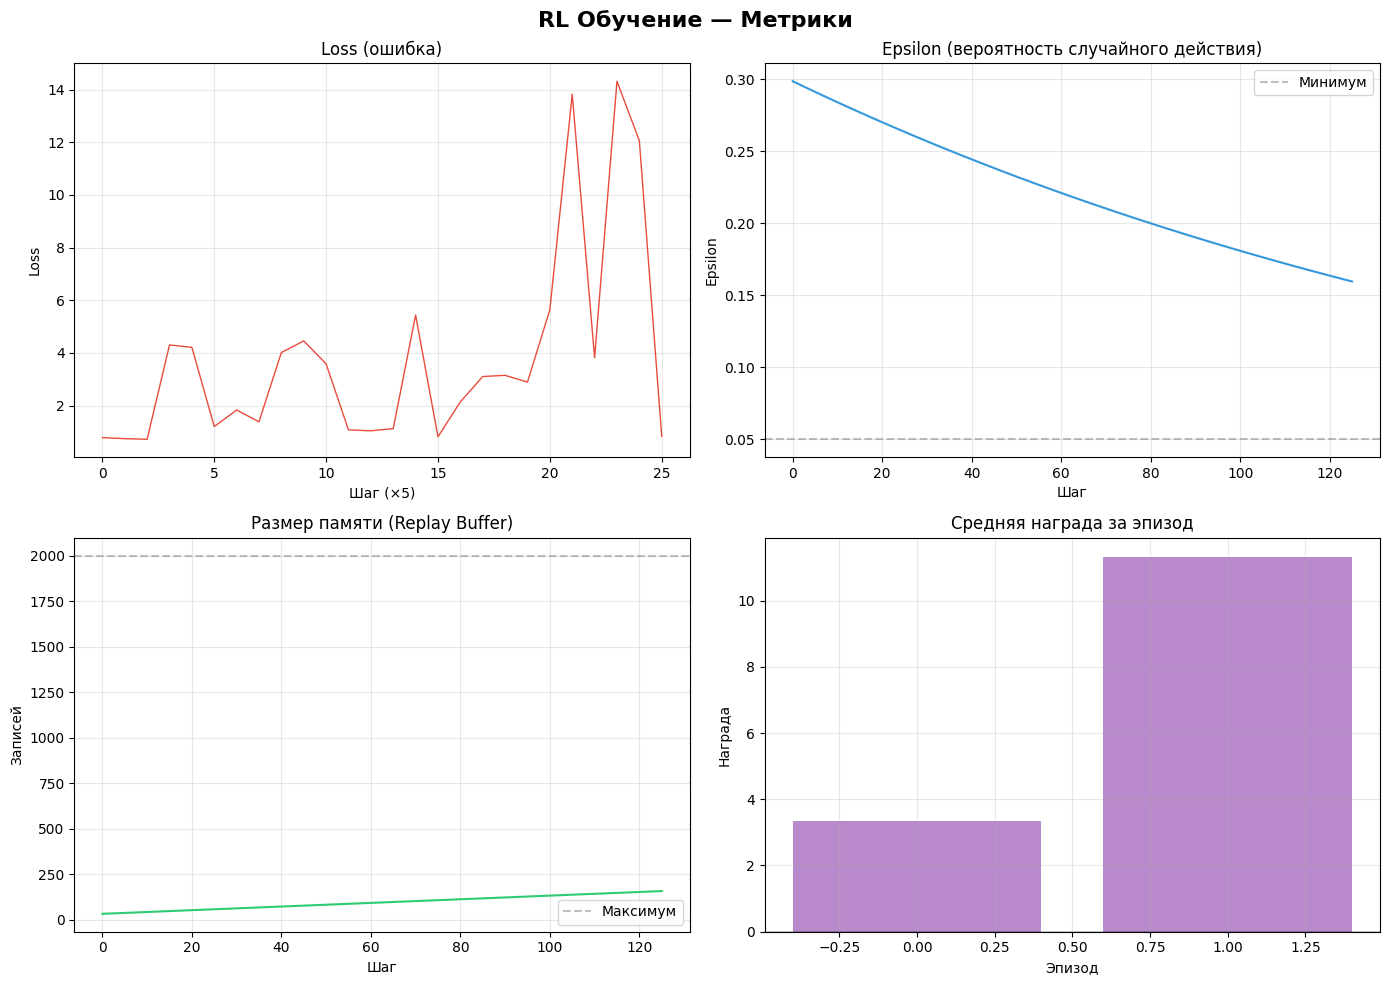


ИТОГОВАЯ СТАТИСТИКА
Всего шагов обучения: 126
Начальный epsilon: 0.298
Конечный epsilon:   0.160
Размер памяти:      157
Всего эпизодов:     2
Последняя награда:  11.33
Максимальная:       11.33
Минимальная:        3.34


In [32]:
import json
import matplotlib.pyplot as plt

# Загружаем метрики
try:
    with open("metrics.json", "r") as f:
        data = json.load(f)
except:
    print("Файл metrics.json не найден! Сначала запусти сервер и поиграй.")
    data = {'loss': [], 'epsilon': [], 'avg_reward': [], 'memory_size': []}

# Рисуем 4 графика
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('RL Обучение — Метрики', fontsize=16, fontweight='bold')

# 1. Loss (ошибка)
if data['loss']:
    # Берём каждый 5-й шаг для скорости
    loss_data = data['loss'][::5]
    axes[0, 0].plot(loss_data, color='#e74c3c', linewidth=1)
    axes[0, 0].set_title('Loss (ошибка)', fontsize=12)
    axes[0, 0].set_xlabel('Шаг (×5)')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)
else:
    axes[0, 0].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[0, 0].transAxes)

# 2. Epsilon (исследование)
if data['epsilon']:
    axes[0, 1].plot(data['epsilon'], color='#3498db', linewidth=1.5)
    axes[0, 1].axhline(y=0.05, color='gray', linestyle='--', alpha=0.5, label='Минимум')
    axes[0, 1].set_title('Epsilon (вероятность случайного действия)', fontsize=12)
    axes[0, 1].set_xlabel('Шаг')
    axes[0, 1].set_ylabel('Epsilon')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[0, 1].transAxes)

# 3. Размер памяти
if data['memory_size']:
    axes[1, 0].plot(data['memory_size'], color='#2ecc71', linewidth=1.5)
    axes[1, 0].axhline(y=2000, color='gray', linestyle='--', alpha=0.5, label='Максимум')
    axes[1, 0].set_title('Размер памяти (Replay Buffer)', fontsize=12)
    axes[1, 0].set_xlabel('Шаг')
    axes[1, 0].set_ylabel('Записей')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[1, 0].transAxes)

# 4. Средняя награда за эпизод
if data['avg_reward']:
    axes[1, 1].bar(range(len(data['avg_reward'])), data['avg_reward'], color='#9b59b6', alpha=0.7)
    axes[1, 1].axhline(y=0, color='black', linewidth=1)
    axes[1, 1].set_title('Средняя награда за эпизод', fontsize=12)
    axes[1, 1].set_xlabel('Эпизод')
    axes[1, 1].set_ylabel('Награда')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Нет данных', ha='center', va='center', transform=axes[1, 1].transAxes)

plt.tight_layout()
plt.show()

# Выводим статистику
print("\n" + "="*50)
print("ИТОГОВАЯ СТАТИСТИКА")
print("="*50)
if data['loss']:
    print(f"Всего шагов обучения: {len(data['loss'])}")
    print(f"Начальный epsilon: {data['epsilon'][0]:.3f}" if data['epsilon'] else "")
    print(f"Конечный epsilon:   {data['epsilon'][-1]:.3f}" if data['epsilon'] else "")
    print(f"Размер памяти:      {data['memory_size'][-1]}" if data['memory_size'] else "")
    print(f"Всего эпизодов:     {len(data['avg_reward'])}")
    if data['avg_reward']:
        print(f"Последняя награда:  {data['avg_reward'][-1]:.2f}")
        print(f"Максимальная:       {max(data['avg_reward']):.2f}")
        print(f"Минимальная:        {min(data['avg_reward']):.2f}")
else:
    print("Данных пока нет. Поиграйте ещё!")
print("="*50)